# Day 8 | Lab 8.1: LangGraph Supervisor — Customer Support Multi-Agent

**Duration:** ~1.5 hours

**Scenario.** ShopSmart e-commerce customer support — preserved from the B4 source notebook. A supervisor agent routes incoming tickets to one of four specialist sub-agents (Order, Returns, Billing, Product), with PII redaction up front, RAG-backed policy lookup, and human-in-the-loop escalation.

**Learning Objectives.** By the end of this lab, you will be able to:
1. Build a **supervisor multi-agent system** in LangGraph that coordinates 4 specialist sub-agents.
2. Create specialist sub-agents with domain-specific tools using LangChain v1's `create_agent`.
3. Implement **Human-in-the-Loop (HITL)** for escalations using `interrupt()` and `Command(resume=...)`.
4. Integrate **RAG** (FAISS + OpenAI embeddings) for policy lookup inside a specialist agent.
5. Apply **PII redaction** before sending customer data to the LLM.
6. Use `MemorySaver` + `InMemoryStore` for multi-turn and cross-session memory.
7. Evaluate routing accuracy across a batch of real tickets.

**Tools.** LangChain v1 (`create_agent`) · LangGraph v1 (`StateGraph`, `interrupt`, `Command`) · FAISS · OpenAI · `gpt-5-mini` (reasoning) + `gpt-4.1-mini` (response generation).

*Created by Prashant Sahu · [LinkedIn](https://www.linkedin.com/in/prashantksahu/)*

---


---

## Section 1: Environment Setup

We install all required packages. This lab uses:
- **LangChain v1** for agent creation (`create_agent`) and tool definitions
- **LangGraph v1** for the supervisor workflow graph
- **FAISS** for the policy knowledge base (RAG)
- **Pydantic** for structured output models

In [ ]:
# Required packages for this lab — already installed in your local venv.
# To install standalone, uncomment the line(s) below:
# !pip install -q 'langchain>=1.0' 'langchain-core>=1.0' 'langchain-openai>=1.0' 'langgraph>=1.0' 'langchain-community>=1.0' 'langchain-text-splitters>=0.3' faiss-cpu pydantic


In [1]:
import os

# Local-venv pattern: load from .env if python-dotenv is available, otherwise rely on
# environment variables already set in your shell or venv activation script.
try:
    from dotenv import load_dotenv
    load_dotenv("..\\.env")
except ImportError:
    pass

for key in ['OPENAI_API_KEY']:
    status = '✅ Loaded' if os.environ.get(key) else '❌ MISSING'
    print(f'{key}: {status}')


OPENAI_API_KEY: ✅ Loaded


In [2]:
# ============================================================
# Import All Required Modules
# ============================================================
import json
import re
import uuid
from datetime import datetime, timedelta
from typing import Annotated, Literal

# Pydantic for structured output
from pydantic import BaseModel, Field

# LangChain core
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langchain_core.documents import Document

# LangChain agents --- using create_agent (NOT deprecated create_react_agent)
from langchain.agents import create_agent

# LangGraph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore

# RAG components
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

print("All imports successful.")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

All imports successful.
Timestamp: 2026-05-04 13:04:15


In [3]:
# ============================================================
# Initialize LLM Instances
# ============================================================
# Primary model: gpt-5-mini (reasoning model --- NO temperature parameter)
llm_primary = ChatOpenAI(model="gpt-5-mini")

# Secondary model: gpt-4.1-mini (supports temperature for response generation)
llm_secondary = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)

print("LLM instances initialized:")
print(f"  Primary:   gpt-5-mini (reasoning model, no temperature)")
print(f"  Secondary: gpt-4.1-mini (temperature=0.3, for response generation)")

LLM instances initialized:
  Primary:   gpt-5-mini (reasoning model, no temperature)
  Secondary: gpt-4.1-mini (temperature=0.3, for response generation)


---

## Section 2: Business Scenario --- ShopSmart Customer Support

### The Problem

**ShopSmart** is a mid-size e-commerce platform processing **50,000 customer support tickets per day**. Their current system is a simple router (what we built in Lab 5) that classifies tickets and sends them to human agents. This approach has several limitations:

| Current Pain Point | Impact |
|-------------------|--------|
| Human agents handle ALL tickets | High cost, slow response times |
| No automated order lookups | Agents spend 40% of time just looking up order status |
| No policy consistency | Different agents give different answers about return policies |
| Platinum customers wait in queue | VIP customers get the same treatment as everyone else |
| No conversation memory | Customers repeat themselves when they call back |

### The Solution: Multi-Agent System

We are building a **Supervisor Multi-Agent System** that:

1. **Supervisor Router** classifies incoming tickets using LLM-based structured output
2. **Quick Answer Node** handles simple order status lookups without an LLM (deterministic path)
3. **4 Specialist Sub-Agents** handle complex tickets with domain-specific tools
4. **RAG Knowledge Base** ensures consistent policy answers across all specialists
5. **HITL Escalation** routes platinum customers and critical tickets to human managers
6. **PII Redaction** protects customer data before it reaches any LLM
7. **Memory** maintains conversation context across multi-turn interactions

### Why This Architecture?

- **Not every path needs AI**: Simple order status queries use deterministic lookups (fast, cheap, reliable)
- **Specialists outperform generalists**: Each sub-agent has focused tools and prompts
- **Humans stay in the loop**: Critical decisions still go to human managers
- **RAG ensures consistency**: All agents reference the same policy knowledge base

---

## Section 3: Multi-Agent Patterns in LangChain v1

Before building, let us understand the multi-agent patterns available in LangChain v1:

| Pattern | How It Works | Best For | Complexity |
|---------|-------------|----------|------------|
| **Subagents** | Main agent invokes sub-agents as tools | Distributed development, strong isolation | Medium |
| **Handoffs** | Agents transfer control via tool calls | Conversational flows, customer service | Medium |
| **Skills** | Single agent loads specialized prompts dynamically | Simple tasks, prompt switching | Low |
| **Router** | Classify input, direct to specialist | Parallel multi-domain processing | Low-Medium |
| **Custom Workflow** | Bespoke `StateGraph` with full control | Maximum control over routing, HITL, branching | High |

### Our Choice: Custom Workflow with Supervisor

We use a **Custom Workflow** pattern with a **Supervisor node** that routes to **specialist sub-agents**. This gives us:

- **Maximum control** over the routing logic and conditional edges
- **HITL triggers** at specific points in the graph (not possible with simple subagents)
- **Deterministic paths** alongside LLM paths (quick_answer node uses no LLM)
- **State management** --- every node can read and write to the shared state

The **supervisor is a custom StateGraph node** (NOT a `create_agent` instance). It handles structured classification. The **4 specialists ARE `create_agent` instances** --- they handle the actual customer interaction with their domain-specific tools.

This hybrid approach (custom supervisor + agent specialists) is a common production pattern because it separates the **routing concern** (which needs precision and structure) from the **interaction concern** (which needs flexibility and tool use).

---

## Section 4: Load Data Files

We load all 5 data files from the current directory:
- **customers.json** --- 10 customers with tier information
- **orders.json** --- 100 orders with status and tracking
- **products.json** --- 20 products with specs and FAQ
- **tickets.json** --- 100 support tickets with categories
- **policies.md** --- ShopSmart policies for RAG

In [4]:
# ============================================================
# Load All Data Files
# ============================================================

# Load JSON data files
with open("customers.json", "r") as f:
    customers_raw = json.load(f)

with open("orders.json", "r") as f:
    orders_raw = json.load(f)

with open("products.json", "r") as f:
    products_raw = json.load(f)

with open("tickets.json", "r") as f:
    TICKETS = json.load(f)

# Load policies as markdown string
with open("policies.md", "r") as f:
    POLICIES = f.read()

# Build indexed databases (dict keyed by ID for O(1) lookup)
CUSTOMERS_DB = {c["customer_id"]: c for c in customers_raw}
ORDERS_DB = {o["order_id"]: o for o in orders_raw}
PRODUCTS_DB = {p["product_id"]: p for p in products_raw}

# Build reverse index: customer_id -> list of orders
CUSTOMER_ORDERS = {}
for order in orders_raw:
    cid = order["customer_id"]
    if cid not in CUSTOMER_ORDERS:
        CUSTOMER_ORDERS[cid] = []
    CUSTOMER_ORDERS[cid].append(order)

# Print summary statistics
print("=" * 60)
print("DATA LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Customers:  {len(CUSTOMERS_DB):>4} records")
print(f"Orders:     {len(ORDERS_DB):>4} records")
print(f"Products:   {len(PRODUCTS_DB):>4} records")
print(f"Tickets:    {len(TICKETS):>4} records")
print(f"Policies:   {len(POLICIES):>4} characters")
print()

# Customer tier distribution
tier_counts = {}
for c in customers_raw:
    tier_counts[c["tier"]] = tier_counts.get(c["tier"], 0) + 1
print("Customer Tier Distribution:")
for tier, count in sorted(tier_counts.items()):
    print(f"  {tier:>10}: {count}")

# Ticket category distribution
print()
cat_counts = {}
for t in TICKETS:
    cat_counts[t["category"]] = cat_counts.get(t["category"], 0) + 1
print("Ticket Category Distribution:")
for cat, count in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f"  {cat:>18}: {count}")

# Order status distribution
print()
status_counts = {}
for o in orders_raw:
    status_counts[o["status"]] = status_counts.get(o["status"], 0) + 1
print("Order Status Distribution:")
for status, count in sorted(status_counts.items(), key=lambda x: -x[1]):
    print(f"  {status:>12}: {count}")

DATA LOADED SUCCESSFULLY
Customers:    10 records
Orders:      100 records
Products:     20 records
Tickets:     100 records
Policies:   2974 characters

Customer Tier Distribution:
      bronze: 5
    platinum: 1
      silver: 4

Ticket Category Distribution:
        order_status: 39
             returns: 17
          escalation: 13
             billing: 13
     product_inquiry: 12
           technical: 6

Order Status Distribution:
     delivered: 65
    in_transit: 19
    processing: 11
     cancelled: 5


---

## Section 5: PII Redaction

**Why PII redaction matters**: Every ticket contains the customer's name, email, and sometimes phone number. Before any ticket text reaches an LLM, we must redact personally identifiable information (PII) to:

1. **Protect customer privacy** --- LLM providers may log inputs
2. **Comply with regulations** --- GDPR, CCPA, etc.
3. **Reduce liability** --- Less PII in transit = less risk

Our redaction approach:
- **Regex-based** for emails and phone numbers (pattern matching)
- **Database-driven** for names (match against known customer names)
- We store the mapping so we can **restore PII** in the final customer-facing response

In [5]:
# ============================================================
# PII Redaction Functions
# ============================================================

# Build a set of all known customer names for name redaction
KNOWN_NAMES = {c["name"] for c in customers_raw}

# Also include first names and last names separately
KNOWN_FIRST_NAMES = {c["name"].split()[0] for c in customers_raw}
KNOWN_LAST_NAMES = {c["name"].split()[-1] for c in customers_raw}


def redact_pii(text: str, customer_id: str = None) -> tuple[str, dict]:
    """
    Redact PII from ticket text before sending to LLM.

    Args:
        text: The raw ticket text containing PII
        customer_id: Optional customer ID to look up specific name/email

    Returns:
        Tuple of (redacted_text, pii_mapping) where pii_mapping can be used
        to restore PII in the final response.
    """
    redacted = text
    pii_mapping = {}  # Maps placeholder -> original value

    # 1. Redact email addresses (regex)
    email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    emails_found = re.findall(email_pattern, redacted)
    for email in emails_found:
        pii_mapping["[EMAIL_REDACTED]"] = email
        redacted = redacted.replace(email, "[EMAIL_REDACTED]")

    # 2. Redact phone numbers (multiple formats)
    phone_pattern = r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b'
    phones_found = re.findall(phone_pattern, redacted)
    for phone in phones_found:
        pii_mapping["[PHONE_REDACTED]"] = phone
        redacted = redacted.replace(phone, "[PHONE_REDACTED]")

    # 3. Redact known customer names (database-driven)
    # First try full names, then individual first/last names
    for name in sorted(KNOWN_NAMES, key=len, reverse=True):  # longest first
        if name in redacted:
            pii_mapping["[NAME_REDACTED]"] = name
            redacted = redacted.replace(name, "[NAME_REDACTED]")

    # If we have a specific customer, also redact their first name alone
    if customer_id and customer_id in CUSTOMERS_DB:
        customer = CUSTOMERS_DB[customer_id]
        first_name = customer["name"].split()[0]
        if first_name in redacted and "[NAME_REDACTED]" not in pii_mapping:
            pii_mapping["[NAME_REDACTED]"] = customer["name"]
            redacted = redacted.replace(first_name, "[NAME_REDACTED]")

    return redacted, pii_mapping


def restore_pii(text: str, pii_mapping: dict) -> str:
    """Restore PII placeholders with original values for customer-facing response."""
    restored = text
    for placeholder, original in pii_mapping.items():
        restored = restored.replace(placeholder, original)
    return restored



In [6]:
# --- Demonstration ---
sample_ticket = TICKETS[0]
print("ORIGINAL ticket text:")
print(f"  {sample_ticket['text']}")
print()

redacted_text, pii_map = redact_pii(sample_ticket["text"], sample_ticket["customer_id"])
print("REDACTED ticket text:")
print(f"  {redacted_text}")
print()
print("PII Mapping (stored securely, never sent to LLM):")
for placeholder, value in pii_map.items():
    print(f"  {placeholder} -> {value}")

ORIGINAL ticket text:
  Hi, I'm Sarah Johnson. My email is sarah.j@email.com. What's the tracking number for order ORD-00050?

REDACTED ticket text:
  Hi, I'm [NAME_REDACTED]. My email is [EMAIL_REDACTED]. What's the tracking number for order ORD-00050?

PII Mapping (stored securely, never sent to LLM):
  [EMAIL_REDACTED] -> sarah.j@email.com
  [NAME_REDACTED] -> Sarah Johnson


---

## Section 6: RAG Knowledge Base for Policy Lookup

All specialist agents need access to ShopSmart's official policies. Instead of stuffing the entire policy document into every prompt (wasteful and context-limited), we use **Retrieval-Augmented Generation (RAG)**:

1. **Split** the policies.md into chunks
2. **Embed** each chunk using `text-embedding-3-small`
3. **Store** embeddings in a FAISS vector store
4. **Retrieve** the most relevant policy sections when agents need them

This ensures every agent gives **consistent, accurate policy answers** regardless of which specialist handles the ticket.

In [7]:
# ============================================================
# Build RAG Knowledge Base from Policies
# ============================================================

# Split the policies document into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n## ", "\n### ", "\n- ", "\n", " "]
)

policy_chunks = text_splitter.split_text(POLICIES)
print(f"Policy document split into {len(policy_chunks)} chunks")
print()

Policy document split into 9 chunks



In [8]:
policy_chunks

['# ShopSmart Customer Support Policies',
 '## Return & Refund Policy\n\n### Return Window\n- Standard items: 30 days from delivery date\n- Electronics: 15 days from delivery date\n- Final sale items: No returns accepted\n\n### Return Conditions\n- Item must be in original condition\n- Original packaging required\n- Receipt or order number required\n- Return shipping: Customer pays unless item is defective',
 '### Refund Processing\n- Refunds processed within 5-7 business days after receiving returned item\n- Original payment method will be credited\n- Shipping costs are non-refundable unless item was defective\n\n### Defective/Damaged Items\n- Full refund including shipping costs\n- Replacement offered at no additional cost\n- Must report within 48 hours of delivery',
 '## Shipping Policy\n\n### Standard Shipping\n- 5-7 business days\n- Free on orders over $50\n- $5.99 for orders under $50\n\n### Express Shipping\n- 2-3 business days\n- $14.99 flat rate\n\n### Tracking\n- Tracking num

In [9]:
# Create Document objects with metadata
policy_docs = [
    Document(page_content=chunk, metadata={"source": "policies.md", "chunk_index": i})
    for i, chunk in enumerate(policy_chunks)
]

# Build FAISS vector store with OpenAI embeddings
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
policy_vectorstore = FAISS.from_documents(policy_docs, embeddings)

# Create retriever (top 3 most relevant chunks)
policy_retriever = policy_vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

print("FAISS vector store created successfully.")
print(f"Total chunks indexed: {len(policy_chunks)}")
print()

FAISS vector store created successfully.
Total chunks indexed: 9



In [10]:
# Quick test: retrieve policy about returns
test_results = policy_retriever.invoke("What is the return policy?")
print("Test query: 'What is the return policy?'")
print(f"Retrieved {len(test_results)} relevant chunks:")
for i, doc in enumerate(test_results):
    print(f"  Chunk {i+1}: {doc.page_content}...")
    print("+"*80)

Test query: 'What is the return policy?'
Retrieved 3 relevant chunks:
  Chunk 1: ## Return & Refund Policy

### Return Window
- Standard items: 30 days from delivery date
- Electronics: 15 days from delivery date
- Final sale items: No returns accepted

### Return Conditions
- Item must be in original condition
- Original packaging required
- Receipt or order number required
- Return shipping: Customer pays unless item is defective...
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Chunk 2: ### Refund Processing
- Refunds processed within 5-7 business days after receiving returned item
- Original payment method will be credited
- Shipping costs are non-refundable unless item was defective

### Defective/Damaged Items
- Full refund including shipping costs
- Replacement offered at no additional cost
- Must report within 48 hours of delivery...
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Chunk 3: # ShopSmart Custom

---

## Section 7: State Definition

The state is the **single source of truth** that flows through every node in our graph. Every node reads from and writes to this shared state. This is the backbone of our multi-agent coordination.

Key design decisions:
- **`messages`** uses `add_messages` reducer to properly append conversation turns
- **`redacted_text`** is the ONLY version of the ticket text that reaches any LLM
- **`tools_used`** tracks which tools were called for observability
- **`needs_escalation`** is set by the supervisor and triggers the HITL path

In [11]:
# ============================================================
# State Definition (TypedDict)
# ============================================================
from typing import TypedDict


class CustomerSupportState(TypedDict):
    """Shared state for the Customer Support Multi-Agent System.

    This state flows through every node in the graph. Each node reads
    what it needs and writes its results.
    """
    # Conversation history (uses add_messages reducer for proper appending)
    messages: Annotated[list, add_messages]

    # Ticket identification
    ticket_id: str
    customer_id: str
    customer_tier: str          # bronze / silver / platinum

    # Ticket content
    ticket_text: str            # Original text (with PII) --- NEVER sent to LLM
    redacted_text: str          # PII-redacted version --- this goes to LLM

    # Classification results (from supervisor)
    category: str               # order_status, returns, billing, product_inquiry, technical, escalation
    priority: str               # low, medium, high, critical
    classification_confidence: float

    # Processing results
    specialist_response: str    # Response generated by specialist agent
    needs_escalation: bool      # True if ticket requires human review
    human_notes: str            # Notes added by human during HITL

    # Final output
    final_response: str         # Formatted customer-facing response

    # Observability
    tools_used: list[str]       # Track which tools were called
    pii_mapping: dict           # Maps placeholders -> original PII values


print("CustomerSupportState defined with", len(CustomerSupportState.__annotations__), "fields.")
print()
print("Fields:")
for field_name, field_type in CustomerSupportState.__annotations__.items():
    print(f"  {field_name:>30}: {field_type}")

CustomerSupportState defined with 15 fields.

Fields:
                        messages: typing.Annotated[list, <function _add_messages_wrapper.<locals>._add_messages at 0x00000245A132BCE0>]
                       ticket_id: <class 'str'>
                     customer_id: <class 'str'>
                   customer_tier: <class 'str'>
                     ticket_text: <class 'str'>
                   redacted_text: <class 'str'>
                        category: <class 'str'>
                        priority: <class 'str'>
       classification_confidence: <class 'float'>
             specialist_response: <class 'str'>
                needs_escalation: <class 'bool'>
                     human_notes: <class 'str'>
                  final_response: <class 'str'>
                      tools_used: list[str]
                     pii_mapping: <class 'dict'>


---

## Section 8: Pydantic Classification Model

The supervisor uses **structured output** to classify tickets. This Pydantic model defines the exact schema the LLM must follow when classifying a ticket. Using structured output eliminates parsing errors and ensures we always get a valid routing decision.

In [12]:
# ============================================================
# Pydantic Classification Model
# ============================================================

class TicketClassification(BaseModel):
    """Structured output for ticket classification by the supervisor.

    The LLM must produce exactly this schema when classifying a ticket.
    This eliminates parsing errors and guarantees valid routing.
    """
    category: Literal[
        "order_status",
        "returns",
        "billing",
        "product_inquiry",
        "technical",
        "escalation"
    ] = Field(description="The primary category of the support ticket")

    priority: Literal[
        "low",
        "medium",
        "high",
        "critical"
    ] = Field(description="Priority level based on urgency and customer tier")

    confidence: float = Field(
        description="Confidence score between 0.0 and 1.0 for the classification",
        ge=0.0,
        le=1.0
    )

    requires_escalation: bool = Field(
        description=(
            "True if the ticket should be escalated to a human manager. "
            "Escalate when: (1) customer explicitly requests a manager, "
            "(2) ticket mentions legal action or social media threats, "
            "(3) category is 'escalation', or "
            "(4) issue involves a high-value dispute over $500."
        )
    )

    reasoning: str = Field(
        description="Brief explanation of why this category and priority were chosen"
    )


print("TicketClassification model defined.")
print(f"Fields: {list(TicketClassification.model_fields.keys())}")

TicketClassification model defined.
Fields: ['category', 'priority', 'confidence', 'requires_escalation', 'reasoning']


---

## Section 9: Tool Definitions

Tools are the **hands** of our specialist agents. Each tool wraps a specific capability --- looking up an order, checking return eligibility, searching the policy knowledge base, etc.

Design principles:
- **Each tool does ONE thing** --- single responsibility
- **Tools return structured data** --- not free-form text
- **Tools access databases directly** --- no LLM calls inside tools
- **Error handling** --- tools return helpful error messages, not exceptions

In [13]:
# ============================================================
# Tool Definitions (10 tools)
# ============================================================

# --- Tool 1: Customer Lookup ---
@tool
def lookup_customer(customer_id: str) -> str:
    """Look up customer information by customer ID.
    Returns customer tier, join date, and ticket history.
    """
    if customer_id not in CUSTOMERS_DB:
        return f"Error: Customer {customer_id} not found in database."
    c = CUSTOMERS_DB[customer_id]
    return json.dumps({
        "customer_id": c["customer_id"],
        "name": "[REDACTED]",  # Never expose name through tool
        "tier": c["tier"],
        "join_date": c["join_date"],
        "past_tickets_count": c["past_tickets_count"],
        "last_contact_date": c["last_contact_date"]
    }, indent=2)


# --- Tool 2: Order Lookup ---
@tool
def lookup_order(order_id: str) -> str:
    """Look up a specific order by order ID.
    Returns order status, items, total, tracking number, and estimated delivery.
    """
    if order_id not in ORDERS_DB:
        return f"Error: Order {order_id} not found in database."
    o = ORDERS_DB[order_id]
    return json.dumps({
        "order_id": o["order_id"],
        "customer_id": o["customer_id"],
        "order_date": o["order_date"],
        "items": [{"name": item["name"], "quantity": item["quantity"], "price": item["price"]} for item in o["items"]],
        "total": o["total"],
        "status": o["status"],
        "tracking_number": o["tracking_number"],
        "estimated_delivery": o["estimated_delivery"]
    }, indent=2)


# --- Tool 3: Search Orders by Customer ---
@tool
def search_orders_by_customer(customer_id: str) -> str:
    """Find all orders for a given customer.
    Returns a summary list of all their orders with status.
    """
    if customer_id not in CUSTOMER_ORDERS:
        return f"No orders found for customer {customer_id}."
    orders = CUSTOMER_ORDERS[customer_id]
    summary = []
    for o in orders:
        summary.append({
            "order_id": o["order_id"],
            "order_date": o["order_date"][:10],
            "total": o["total"],
            "status": o["status"],
            "items_count": len(o["items"])
        })
    return json.dumps({"customer_id": customer_id, "order_count": len(summary), "orders": summary}, indent=2)


# --- Tool 4: Check Return Eligibility ---
@tool
def check_return_eligibility(order_id: str) -> str:
    """Check if an order is eligible for return based on ShopSmart's return policy.
    Standard items: 30 days from delivery. Electronics: 15 days.
    """
    if order_id not in ORDERS_DB:
        return f"Error: Order {order_id} not found."

    order = ORDERS_DB[order_id]

    # Must be delivered to return
    if order["status"] != "delivered":
        return json.dumps({
            "order_id": order_id,
            "eligible": False,
            "reason": f"Order status is '{order['status']}'. Must be 'delivered' to process a return."
        })

    # Check delivery date (use estimated_delivery as proxy for actual delivery)
    delivery_date = datetime.fromisoformat(order["estimated_delivery"])
    now = datetime.now()
    days_since_delivery = (now - delivery_date).days

    # Determine return window based on product category
    has_electronics = False
    for item in order["items"]:
        pid = item.get("product_id", "")
        if pid in PRODUCTS_DB and PRODUCTS_DB[pid]["category"] == "Electronics":
            has_electronics = True
            break

    return_window = 15 if has_electronics else 30
    eligible = days_since_delivery <= return_window

    return json.dumps({
        "order_id": order_id,
        "eligible": eligible,
        "days_since_delivery": days_since_delivery,
        "return_window_days": return_window,
        "contains_electronics": has_electronics,
        "reason": "Within return window" if eligible else f"Return window of {return_window} days has expired ({days_since_delivery} days since delivery)"
    }, indent=2)


# --- Tool 5: Product Lookup ---
@tool
def lookup_product(product_id: str) -> str:
    """Look up detailed product information by product ID.
    Returns name, category, price, stock status, specs, and FAQ.
    """
    if product_id not in PRODUCTS_DB:
        return f"Error: Product {product_id} not found."
    p = PRODUCTS_DB[product_id]
    return json.dumps(p, indent=2)


# --- Tool 6: Search Products ---
@tool
def search_products(query: str) -> str:
    """Search products by name or category. Case-insensitive partial matching.
    Use this when the customer asks about a product by name.
    """
    query_lower = query.lower()
    results = []
    for p in PRODUCTS_DB.values():
        if query_lower in p["name"].lower() or query_lower in p["category"].lower():
            results.append({
                "product_id": p["product_id"],
                "name": p["name"],
                "category": p["category"],
                "price": p["price"],
                "stock_status": p["stock_status"]
            })
    if not results:
        return f"No products found matching '{query}'."
    return json.dumps({"query": query, "results_count": len(results), "results": results}, indent=2)


# --- Tool 7: Policy Lookup (RAG) ---
@tool
def policy_lookup(query: str) -> str:
    """Search ShopSmart's official policies using semantic search.
    Use this to get accurate policy information about returns, shipping, billing, etc.
    """
    results = policy_retriever.invoke(query)
    if not results:
        return "No relevant policy information found."
    policy_text = "\n\n---\n\n".join([doc.page_content for doc in results])
    return f"Relevant ShopSmart Policies:\n\n{policy_text}"


# --- Tool 8: Calculate Refund ---
@tool
def calculate_refund(order_id: str, reason: str) -> str:
    """Calculate the refund amount for an order based on the return reason.
    Defective items get full refund including shipping. Other returns exclude shipping.
    """
    if order_id not in ORDERS_DB:
        return f"Error: Order {order_id} not found."

    order = ORDERS_DB[order_id]
    total = order["total"]

    reason_lower = reason.lower()
    is_defective = any(word in reason_lower for word in ["defective", "damaged", "broken", "wrong item", "incorrect"])

    if is_defective:
        refund_amount = total  # Full refund including shipping
        refund_type = "full (defective/damaged item)"
    else:
        # Subtract estimated shipping cost for non-defective returns
        shipping_cost = 0.0 if total > 50 else 5.99
        refund_amount = total - shipping_cost
        refund_type = "partial (shipping costs excluded)"

    return json.dumps({
        "order_id": order_id,
        "order_total": total,
        "refund_amount": round(refund_amount, 2),
        "refund_type": refund_type,
        "reason": reason,
        "processing_time": "5-7 business days"
    }, indent=2)


# --- Tool 9: Check Billing Status ---
@tool
def check_billing_status(customer_id: str) -> str:
    """Check recent billing and payment information for a customer.
    Returns summary of recent orders and their payment status.
    """
    if customer_id not in CUSTOMER_ORDERS:
        return f"No billing records found for customer {customer_id}."

    orders = CUSTOMER_ORDERS[customer_id]
    # Get the 5 most recent orders
    recent = sorted(orders, key=lambda o: o["order_date"], reverse=True)[:5]

    billing_records = []
    for o in recent:
        billing_records.append({
            "order_id": o["order_id"],
            "order_date": o["order_date"][:10],
            "total": o["total"],
            "status": o["status"],
            "payment_status": "charged" if o["status"] != "cancelled" else "refunded"
        })

    return json.dumps({
        "customer_id": customer_id,
        "recent_billing": billing_records,
        "total_recent_charges": sum(r["total"] for r in billing_records if r["payment_status"] == "charged")
    }, indent=2)


# --- Tool 10: Escalate to Manager ---
@tool
def escalate_to_manager(reason: str) -> str:
    """Flag a ticket for escalation to a human support manager.
    Use when the issue is beyond automated handling capabilities.
    """
    escalation_id = f"ESC-{uuid.uuid4().hex[:8].upper()}"
    return json.dumps({
        "escalation_id": escalation_id,
        "status": "escalated",
        "reason": reason,
        "message": "Ticket has been flagged for human manager review. Expected response within 2 hours."
    }, indent=2)



In [14]:
# Print tool inventory
all_tools = [
    lookup_customer, lookup_order, search_orders_by_customer,
    check_return_eligibility, lookup_product, search_products,
    policy_lookup, calculate_refund, check_billing_status, escalate_to_manager
]
print(f"Total tools defined: {len(all_tools)}")
print()

for i, t in enumerate(all_tools, 1):
    print(f"  {i:>2}. {t.name:<30} --- {t.description.split(chr(10))[0]}")

Total tools defined: 10

   1. lookup_customer                --- Look up customer information by customer ID.
   2. lookup_order                   --- Look up a specific order by order ID.
   3. search_orders_by_customer      --- Find all orders for a given customer.
   4. check_return_eligibility       --- Check if an order is eligible for return based on ShopSmart's return policy.
   5. lookup_product                 --- Look up detailed product information by product ID.
   6. search_products                --- Search products by name or category. Case-insensitive partial matching.
   7. policy_lookup                  --- Search ShopSmart's official policies using semantic search.
   8. calculate_refund               --- Calculate the refund amount for an order based on the return reason.
   9. check_billing_status           --- Check recent billing and payment information for a customer.
  10. escalate_to_manager            --- Flag a ticket for escalation to a human support manag

---

## Section 10: Supervisor Router Node

The **Supervisor** is the brain of our system. It is a **custom StateGraph node** (not a `create_agent` instance) because:

1. It needs **structured output** (TicketClassification Pydantic model)
2. It checks **business rules** beyond what the LLM classifies (e.g., platinum tier + high priority = escalate)
3. It does NOT need tools --- it only reads the ticket text and produces a routing decision

The supervisor also determines whether the ticket can be handled by the **deterministic quick-answer path** (no LLM needed for simple order status lookups).

In [15]:
# ============================================================
# Supervisor Router Node
# ============================================================

# Create a structured-output LLM for classification
classifier_llm = llm_primary.with_structured_output(TicketClassification)

SUPERVISOR_SYSTEM_PROMPT = """You are the ticket classification supervisor for ShopSmart customer support.

Your job is to classify incoming support tickets into the correct category and priority.

Categories:
- order_status: Questions about where an order is, tracking info, delivery estimates
- returns: Return requests, exchange requests, damaged/defective items
- billing: Payment issues, charges, invoices, refund status
- product_inquiry: Product questions, availability, specifications, recommendations
- technical: Account access issues, website problems, password resets
- escalation: Customer explicitly requests a manager, mentions legal action, or expresses extreme dissatisfaction

Priority guidelines:
- low: Simple questions, informational requests
- medium: Standard issues requiring action
- high: Urgent issues, frustrated customers, time-sensitive problems
- critical: Legal threats, safety issues, high-value disputes ($500+)

Escalation triggers (set requires_escalation=True):
- Customer explicitly asks for a manager or supervisor
- Mentions legal action, lawyer, or regulatory complaint
- Mentions social media threats ("I'll post this everywhere")
- Category is clearly 'escalation'
- High-value dispute over $500

Be precise and confident in your classification."""


def supervisor_router(state: CustomerSupportState) -> dict:
    """
    Supervisor node: classifies the ticket and determines routing.

    This node:
    1. Takes the redacted ticket text
    2. Uses LLM with structured output to classify
    3. Applies business rules for escalation overrides
    4. Returns the classification results to state
    """
    redacted_text = state["redacted_text"]
    customer_tier = state.get("customer_tier", "bronze")

    # Classify using structured output
    classification = classifier_llm.invoke([
        SystemMessage(content=SUPERVISOR_SYSTEM_PROMPT),
        HumanMessage(content=f"Classify this support ticket:\n\n{redacted_text}")
    ])

    # Apply business rule overrides
    needs_escalation = classification.requires_escalation

    # Override: Platinum customers with high/critical priority ALWAYS escalate
    if customer_tier == "platinum" and classification.priority in ["high", "critical"]:
        needs_escalation = True

    # Override: Low confidence classifications escalate for human review
    if classification.confidence < 0.6:
        needs_escalation = True

    # Override: Explicit escalation category always escalates
    if classification.category == "escalation":
        needs_escalation = True

    print(f"  [Supervisor] Category: {classification.category} | Priority: {classification.priority} | "
          f"Confidence: {classification.confidence:.2f} | Escalation: {needs_escalation}")
    print(f"  [Supervisor] Reasoning: {classification.reasoning}")

    return {
        "category": classification.category,
        "priority": classification.priority,
        "classification_confidence": classification.confidence,
        "needs_escalation": needs_escalation,
        "tools_used": ["supervisor_classifier"],
        "messages": [
            AIMessage(content=f"Ticket classified as {classification.category} (priority: {classification.priority})")
        ]
    }


print("Supervisor router node defined.")

Supervisor router node defined.


---

## Section 11: Quick-Answer Node (Deterministic)

**Not every path needs AI.** For simple order status queries that mention a specific order ID, we can look up the order directly from the database. This is:
- **Faster** --- no LLM call needed
- **Cheaper** --- zero token cost
- **More reliable** --- deterministic lookups never hallucinate

The quick-answer node handles the simplest case: "Where is my order ORD-XXXXX?"

In [16]:
# ============================================================
# Quick-Answer Node (Deterministic, No LLM)
# ============================================================

def quick_answer_node(state: CustomerSupportState) -> dict:
    """
    Deterministic quick-answer node for simple order status lookups.

    If the ticket mentions a specific order ID and the category is order_status,
    we look it up directly without calling an LLM.
    """
    redacted_text = state["redacted_text"]

    # Extract order ID from ticket text using regex
    order_match = re.search(r'ORD-\d{5}', redacted_text)

    if not order_match:
        # No specific order ID found --- cannot do quick answer
        return {
            "specialist_response": "I'd be happy to help with your order. Could you please provide your order number?",
            "tools_used": state.get("tools_used", []) + ["quick_answer_fallback"]
        }

    order_id = order_match.group()

    if order_id not in ORDERS_DB:
        return {
            "specialist_response": f"I could not find order {order_id} in our system. Please double-check the order number and try again.",
            "tools_used": state.get("tools_used", []) + ["quick_answer_lookup"]
        }

    order = ORDERS_DB[order_id]

    # Build deterministic response based on order status
    status = order["status"]
    tracking = order["tracking_number"]
    est_delivery = order["estimated_delivery"][:10]
    items_summary = ", ".join([item["name"] for item in order["items"]])

    status_messages = {
        "delivered": f"Your order {order_id} ({items_summary}) has been delivered. Tracking: {tracking}.",
        "in_transit": f"Your order {order_id} ({items_summary}) is currently in transit. Tracking: {tracking}. Estimated delivery: {est_delivery}.",
        "processing": f"Your order {order_id} ({items_summary}) is currently being processed. Tracking will be available once shipped. Estimated delivery: {est_delivery}.",
        "cancelled": f"Your order {order_id} ({items_summary}) was cancelled. If you did not request this cancellation, please let us know."
    }

    response = status_messages.get(status, f"Your order {order_id} has status: {status}.")

    print(f"  [Quick Answer] Deterministic lookup for {order_id} -> status: {status}")

    return {
        "specialist_response": response,
        "tools_used": state.get("tools_used", []) + ["quick_answer_lookup"]
    }


print("Quick-answer node defined (deterministic, no LLM).")

Quick-answer node defined (deterministic, no LLM).


---

## Section 12: Specialist Sub-Agents

Now we create the 4 specialist agents using `create_agent` from `langchain.agents`. Each specialist has:
- A **focused system prompt** describing its domain expertise
- A **curated set of tools** --- only the tools relevant to its domain
- A **unique name** for observability and tracing

**Why `create_agent` instead of raw LLM calls?** The `create_agent` function provides:
- Automatic tool-calling loop (agent calls tools, reads results, decides next step)
- Proper message formatting for the model
- Built-in error handling for tool failures

**Important**: The supervisor is NOT a `create_agent` instance. It is a custom node that does structured classification. Only the specialists use `create_agent` because they need the tool-calling loop.

In [ ]:
# ============================================================
# Create Specialist Sub-Agents
# ============================================================

# --- Order Specialist ---
order_specialist = create_agent(
    "openai:gpt-5-mini",
    tools=[lookup_order, search_orders_by_customer, lookup_customer],
    system_prompt=(
        "You are ShopSmart's order specialist. Help customers with order tracking, "
        "delivery status, and order issues.\n\n"
        "Guidelines:\n"
        "- Always look up the specific order when an order ID is mentioned\n"
        "- If no order ID is provided, search by customer ID\n"
        "- Provide specific tracking details and estimated delivery dates\n"
        "- Be empathetic if the order is delayed\n"
        "- For cancelled orders, explain next steps"
    ),
    name="order_specialist"
)

# --- Returns Specialist ---
returns_specialist = create_agent(
    "openai:gpt-5-mini",
    tools=[lookup_order, check_return_eligibility, calculate_refund, policy_lookup],
    system_prompt=(
        "You are ShopSmart's returns specialist. Help with return requests, "
        "refund calculations, and exchange policies.\n\n"
        "Guidelines:\n"
        "- ALWAYS check return eligibility before promising a return\n"
        "- Look up the order to verify it exists and is delivered\n"
        "- Use policy_lookup for any policy questions\n"
        "- Calculate the refund amount before confirming\n"
        "- Clearly explain the return process and timeline"
    ),
    name="returns_specialist"
)

# --- Billing Specialist ---
billing_specialist = create_agent(
    "openai:gpt-5-mini",
    tools=[check_billing_status, lookup_customer, lookup_order, policy_lookup],
    system_prompt=(
        "You are ShopSmart's billing specialist. Help with payment issues, "
        "billing disputes, and invoice questions.\n\n"
        "Guidelines:\n"
        "- Check the customer's billing status for recent charges\n"
        "- Look up specific orders if mentioned\n"
        "- Reference official policies for billing disputes\n"
        "- For double charges, assure quick resolution (within 24 hours)\n"
        "- Never disclose full payment details, only last 4 digits"
    ),
    name="billing_specialist"
)

# --- Product Specialist ---
product_specialist = create_agent(
    "openai:gpt-5-mini",
    tools=[lookup_product, search_products, policy_lookup],
    system_prompt=(
        "You are ShopSmart's product specialist. Help with product questions, "
        "availability, specifications, and recommendations.\n\n"
        "Guidelines:\n"
        "- Search for products by name when no product ID is given\n"
        "- Provide specifications, pricing, and stock status\n"
        "- Reference product FAQ when available\n"
        "- If a product is out of stock, suggest alternatives\n"
        "- Use policy_lookup for warranty and return questions"
    ),
    name="product_specialist"
)

print("4 Specialist Sub-Agents created:")
print("  1. order_specialist   --- Tools: lookup_order, search_orders_by_customer, lookup_customer")
print("  2. returns_specialist --- Tools: lookup_order, check_return_eligibility, calculate_refund, policy_lookup")
print("  3. billing_specialist --- Tools: check_billing_status, lookup_customer, lookup_order, policy_lookup")
print("  4. product_specialist --- Tools: lookup_product, search_products, policy_lookup")

4 Specialist Sub-Agents created:
  1. order_specialist   --- Tools: lookup_order, search_orders_by_customer, lookup_customer
  2. returns_specialist --- Tools: lookup_order, check_return_eligibility, calculate_refund, policy_lookup
  3. billing_specialist --- Tools: check_billing_status, lookup_customer, lookup_order, policy_lookup
  4. product_specialist --- Tools: lookup_product, search_products, policy_lookup


---

## Section 13: Specialist Handler Nodes

Each specialist agent needs a **handler node** --- a function that wraps the `create_agent` instance into a LangGraph node. The handler:

1. Extracts the relevant context from the shared state
2. Invokes the specialist agent with the redacted ticket text
3. Captures the specialist's response and updates the state
4. Tracks which tools the specialist called

In [18]:
# ============================================================
# Specialist Handler Nodes
# ============================================================

def _invoke_specialist(agent, agent_name: str, state: CustomerSupportState) -> dict:
    """Generic helper to invoke a specialist agent and capture results."""
    redacted_text = state["redacted_text"]
    customer_id = state.get("customer_id", "unknown")

    # Build context message for the specialist
    context = (
        f"Customer ID: {customer_id}\n"
        f"Ticket Category: {state.get('category', 'unknown')}\n"
        f"Priority: {state.get('priority', 'unknown')}\n"
        f"\nCustomer Message:\n{redacted_text}"
    )

    print(f"  [{agent_name}] Processing ticket...")

    # Invoke the specialist agent
    result = agent.invoke(
        {"messages": [{"role": "user", "content": context}]}
    )

    # Extract the final response from the agent's messages
    # The last AI message is the specialist's response
    response_text = ""
    if "messages" in result:
        for msg in reversed(result["messages"]):
            if hasattr(msg, "content") and msg.content and not hasattr(msg, "tool_calls"):
                response_text = msg.content
                break

    if not response_text:
        response_text = "I apologize, but I was unable to process your request. Let me transfer you to a human agent."

    print(f"  [{agent_name}] Response generated ({len(response_text)} chars)")

    return {
        "specialist_response": response_text,
        "tools_used": state.get("tools_used", []) + [agent_name],
        "messages": [AIMessage(content=f"[{agent_name}] {response_text[:200]}...")]
    }


# --- Handler for Order Specialist ---
def handle_order(state: CustomerSupportState) -> dict:
    """Handler node that invokes the order specialist agent."""
    return _invoke_specialist(order_specialist, "order_specialist", state)


# --- Handler for Returns Specialist ---
def handle_returns(state: CustomerSupportState) -> dict:
    """Handler node that invokes the returns specialist agent."""
    return _invoke_specialist(returns_specialist, "returns_specialist", state)


# --- Handler for Billing Specialist ---
def handle_billing(state: CustomerSupportState) -> dict:
    """Handler node that invokes the billing specialist agent."""
    return _invoke_specialist(billing_specialist, "billing_specialist", state)


# --- Handler for Product Specialist ---
def handle_product(state: CustomerSupportState) -> dict:
    """Handler node that invokes the product specialist agent."""
    return _invoke_specialist(product_specialist, "product_specialist", state)


print("4 Specialist handler nodes defined:")
print("  handle_order, handle_returns, handle_billing, handle_product")

4 Specialist handler nodes defined:
  handle_order, handle_returns, handle_billing, handle_product


---

## Section 14: HITL Escalation Node

The **Human-in-the-Loop (HITL) escalation node** uses `interrupt()` to pause the graph and wait for a human manager to review the ticket. This is triggered when:

1. **Platinum customer** with high/critical priority --- VIP treatment
2. **Category is "escalation"** --- customer explicitly requested a manager
3. **Classification confidence < 0.6** --- the LLM is unsure

The `interrupt()` call returns a rich payload with all the ticket context. A human manager reviews it and provides notes using `Command(resume=...)`.

**This is the same pattern from Lab 8**, now integrated into a production multi-agent system.

In [19]:
# ============================================================
# HITL Escalation Node
# ============================================================

def escalation_hitl_node(state: CustomerSupportState) -> dict:
    """
    Human-in-the-loop escalation node.

    Pauses the graph with interrupt() so a human manager can review the ticket.
    The human provides notes/instructions via Command(resume=...).
    """
    ticket_id = state.get("ticket_id", "unknown")
    customer_id = state.get("customer_id", "unknown")
    customer_tier = state.get("customer_tier", "unknown")
    category = state.get("category", "unknown")
    priority = state.get("priority", "unknown")
    redacted_text = state["redacted_text"]
    confidence = state.get("classification_confidence", 0.0)

    # Build escalation reason
    reasons = []
    if customer_tier == "platinum":
        reasons.append("Platinum customer (VIP)")
    if category == "escalation":
        reasons.append("Customer requested escalation")
    if confidence < 0.6:
        reasons.append(f"Low classification confidence ({confidence:.2f})")
    if priority in ["high", "critical"]:
        reasons.append(f"{priority.capitalize()} priority ticket")

    escalation_reason = "; ".join(reasons) if reasons else "Manual escalation"

    print(f"  [HITL] Escalation triggered for ticket {ticket_id}")
    print(f"  [HITL] Reason: {escalation_reason}")
    print(f"  [HITL] Waiting for human manager input...")

    # Interrupt with rich payload for the human reviewer
    human_input = interrupt({
        "action": "escalation_review",
        "ticket_id": ticket_id,
        "customer_id": customer_id,
        "customer_tier": customer_tier,
        "category": category,
        "priority": priority,
        "classification_confidence": confidence,
        "redacted_text": redacted_text,
        "escalation_reason": escalation_reason,
        "instructions": (
            "Please review this ticket and provide:\n"
            "1. Your resolution notes\n"
            "2. Any special instructions for the customer response"
        )
    })

    # Human has responded via Command(resume=...)
    human_notes = human_input if isinstance(human_input, str) else str(human_input)

    print(f"  [HITL] Human manager responded: {human_notes[:100]}...")

    return {
        "specialist_response": f"[Manager Review] {human_notes}",
        "human_notes": human_notes,
        "tools_used": state.get("tools_used", []) + ["escalation_hitl"],
        "messages": [AIMessage(content=f"Ticket escalated. Manager notes: {human_notes[:200]}")]
    }


print("HITL escalation node defined.")
print("Triggers: platinum+high/critical, category=escalation, confidence<0.6")

HITL escalation node defined.
Triggers: platinum+high/critical, category=escalation, confidence<0.6


---

## Section 15: Response Formatter Node

The **Response Formatter** is the final node before the customer sees the response. It:

1. Takes the specialist's response (which used redacted text)
2. Restores the customer's name (from PII mapping) for a personalized greeting
3. Formats it as a professional customer-facing response
4. Adds ShopSmart branding/signature

We use `gpt-4.1-mini` (with temperature=0.3) here because we want slight variation in the formatting while keeping the content consistent.

In [20]:
# ============================================================
# Response Formatter Node
# ============================================================

def format_response_node(state: CustomerSupportState) -> dict:
    """
    Format the specialist's response into a professional customer-facing message.
    Restores customer name from PII mapping for personalization.
    """
    specialist_response = state.get("specialist_response", "")
    pii_mapping = state.get("pii_mapping", {})
    customer_id = state.get("customer_id", "")
    ticket_id = state.get("ticket_id", "")

    # Get customer name for greeting (from database, not from LLM output)
    customer_name = "Valued Customer"
    if customer_id in CUSTOMERS_DB:
        customer_name = CUSTOMERS_DB[customer_id]["name"].split()[0]  # First name

    # Use LLM to format the response professionally
    format_prompt = f"""Rewrite the following customer support response as a professional,
friendly email response from ShopSmart Customer Support.

Customer's first name: {customer_name}
Ticket ID: {ticket_id}

Guidelines:
- Start with a personalized greeting using the customer's first name
- Be empathetic and professional
- Include all the specific details from the response (order numbers, tracking, dates)
- End with an offer for further assistance
- Sign off as "ShopSmart Customer Support Team"
- Keep it concise but complete

Original response to reformat:
{specialist_response}"""

    formatted = llm_secondary.invoke([
        HumanMessage(content=format_prompt)
    ])

    final_response = formatted.content

    print(f"  [Formatter] Response formatted ({len(final_response)} chars)")

    return {
        "final_response": final_response,
        "tools_used": state.get("tools_used", []) + ["response_formatter"]
    }


print("Response formatter node defined (uses gpt-4.1-mini with temp=0.3).")

Response formatter node defined (uses gpt-4.1-mini with temp=0.3).


---

## Section 16: Build the Full Graph

Now we assemble all the nodes and edges into the complete `StateGraph`. This is where the entire architecture comes together:

```
START -> supervisor -> [conditional routing] -> specialist/quick_answer/escalation -> format_response -> END
```

The **conditional edges** from the supervisor determine which path each ticket takes. The routing function checks both the classified category AND the escalation flag.

In [21]:
# ============================================================
# Routing Function for Conditional Edges
# ============================================================

def route_ticket(state: CustomerSupportState) -> str:
    """
    Routing function used by conditional edges after the supervisor.

    Determines which handler node should process the ticket based on:
    1. Whether escalation is needed (overrides everything)
    2. Whether it is a simple order status query (quick_answer path)
    3. The classified category (routes to appropriate specialist)
    """
    # Check escalation first (highest priority)
    if state.get("needs_escalation", False):
        return "escalation"

    category = state.get("category", "")

    # For order_status with a specific order ID, use quick_answer (no LLM)
    if category == "order_status":
        redacted_text = state.get("redacted_text", "")
        has_order_id = bool(re.search(r'ORD-\d{5}', redacted_text))
        if has_order_id:
            return "quick_answer"
        return "order_handler"  # No specific order ID, needs agent to investigate

    # Route to appropriate specialist
    category_to_handler = {
        "returns": "returns_handler",
        "billing": "billing_handler",
        "product_inquiry": "product_handler",
        "technical": "order_handler",  # Technical issues handled by order specialist for now
        "escalation": "escalation",
    }

    return category_to_handler.get(category, "order_handler")


print("Routing function defined.")
print("Routes: quick_answer, order_handler, returns_handler, billing_handler, product_handler, escalation")

Routing function defined.
Routes: quick_answer, order_handler, returns_handler, billing_handler, product_handler, escalation


In [22]:
# ============================================================
# Build the Complete StateGraph
# ============================================================

builder = StateGraph(CustomerSupportState)

# --- Add Nodes ---
builder.add_node("supervisor", supervisor_router)
builder.add_node("quick_answer", quick_answer_node)
builder.add_node("order_handler", handle_order)
builder.add_node("returns_handler", handle_returns)
builder.add_node("billing_handler", handle_billing)
builder.add_node("product_handler", handle_product)
builder.add_node("escalation", escalation_hitl_node)
builder.add_node("format_response", format_response_node)

# --- Add Edges ---

# Entry point: START -> supervisor
builder.add_edge(START, "supervisor")

# Conditional edges from supervisor based on routing function
builder.add_conditional_edges(
    "supervisor",
    route_ticket,
    {
        "quick_answer": "quick_answer",
        "order_handler": "order_handler",
        "returns_handler": "returns_handler",
        "billing_handler": "billing_handler",
        "product_handler": "product_handler",
        "escalation": "escalation",
    }
)

# All handlers flow to format_response
handler_nodes = [
    "quick_answer", "order_handler", "returns_handler",
    "billing_handler", "product_handler", "escalation"
]
for handler in handler_nodes:
    builder.add_edge(handler, "format_response")

# format_response -> END
builder.add_edge("format_response", END)

# --- Compile with Checkpointer and Store ---
memory = MemorySaver()       # Thread-level conversation memory
store = InMemoryStore()      # Cross-session customer history store

graph = builder.compile(
    checkpointer=memory,
    store=store
)

print("Graph compiled successfully!")
print(f"Nodes: {len(handler_nodes) + 2} (supervisor + {len(handler_nodes)} handlers + format_response)")
print(f"Checkpointer: MemorySaver (thread-level memory)")
print(f"Store: InMemoryStore (cross-session customer history)")

Graph compiled successfully!
Nodes: 8 (supervisor + 6 handlers + format_response)
Checkpointer: MemorySaver (thread-level memory)
Store: InMemoryStore (cross-session customer history)


---

## Section 17: Visualize the Architecture

Let us visualize our multi-agent graph to verify the architecture matches our design.

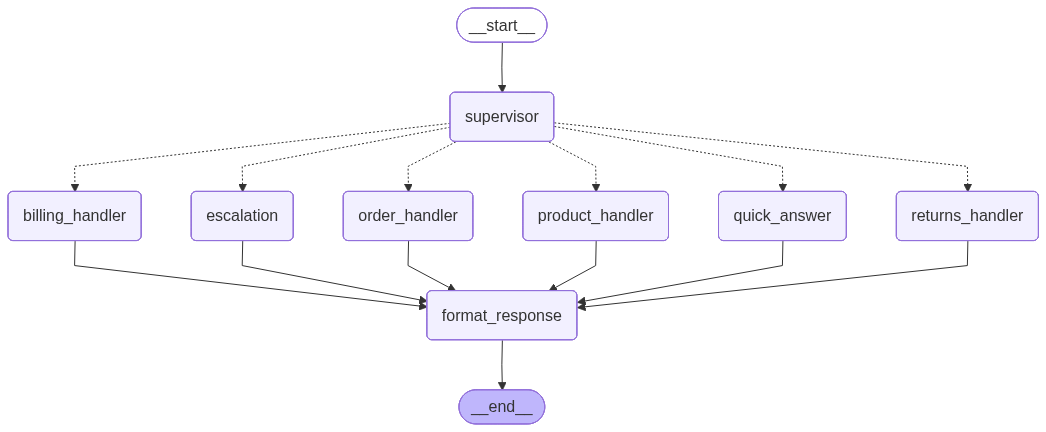

In [23]:
# ============================================================
# Visualize the Graph (Mermaid Diagram)
# ============================================================
from IPython.display import display, Image

try:
    # Try to render as PNG image
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print Mermaid text (can paste into mermaid.live)
    print("Mermaid diagram (paste into https://mermaid.live to visualize):")
    print()
    print(graph.get_graph().draw_mermaid())

---

## Section 18: Helper Function to Process Tickets

Before running test cases, we define a helper function that prepares a ticket from our dataset and runs it through the graph. This handles PII redaction, state initialization, and result extraction.

In [24]:
# ============================================================
# CELL 20: Helper Function to Process a Ticket
# ============================================================

def process_ticket(ticket: dict, thread_id: str = None) -> dict:
    """
    Process a single ticket through the full multi-agent system.

    Args:
        ticket: A ticket dict from tickets.json
        thread_id: Optional thread ID for conversation continuity

    Returns:
        The final state after processing
    """

    print(ticket["text"])

    if thread_id is None:
        thread_id = f"thread-{ticket['ticket_id']}"

    # Look up customer info
    customer_id = ticket["customer_id"]
    customer = CUSTOMERS_DB.get(customer_id, {})
    customer_tier = customer.get("tier", "bronze")

    # Apply PII redaction
    redacted_text, pii_mapping = redact_pii(ticket["text"], customer_id)

    # Prepare initial state
    initial_state = {
        "messages": [HumanMessage(content=redacted_text)],
        "ticket_id": ticket["ticket_id"],
        "customer_id": customer_id,
        "customer_tier": customer_tier,
        "ticket_text": ticket["text"],
        "redacted_text": redacted_text,
        "category": "",
        "priority": "",
        "classification_confidence": 0.0,
        "specialist_response": "",
        "needs_escalation": False,
        "human_notes": "",
        "final_response": "",
        "tools_used": [],
        "pii_mapping": pii_mapping
    }

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    print("=" * 70)
    print(f"PROCESSING TICKET: {ticket['ticket_id']}")
    print(f"Customer: {customer_id} (Tier: {customer_tier})")
    print(f"Original Category: {ticket['category']} | Priority: {ticket['priority']}")
    print(f"Redacted Text: {redacted_text}")
    print("-" * 70)

    # Run the graph
    result = graph.invoke(initial_state, config)

    print("-" * 70)
    print(f"Classified Category: {result.get('category', 'N/A')}")
    print(f"Classified Priority: {result.get('priority', 'N/A')}")
    print(f"Nodes Triggered: {result.get('tools_used', [])}")
    print(f"Escalation: {result.get('needs_escalation', False)}")
    print()
    print("FINAL RESPONSE:")
    print(result.get("final_response", "No response generated."))
    print("=" * 70)

    return result, config


print("process_ticket() helper function defined.")

process_ticket() helper function defined.


---

## Section 19: Test Case 1 --- Simple Order Status (Quick Answer Path)

This test verifies the **deterministic quick-answer path**. The ticket mentions a specific order ID, so the supervisor classifies it as `order_status` and the router sends it to the `quick_answer` node --- **no LLM is used for the actual lookup**.

**Expected flow:** `START -> supervisor -> quick_answer -> format_response -> END`

In [25]:
# ============================================================
# Test Case 1 --- Simple Order Status (Quick Answer)
# ============================================================
# TKT-00001: "What's the tracking number for order ORD-00050?"
# Expected: order_status -> quick_answer (deterministic lookup)

test_ticket_1 = TICKETS[0]  # TKT-00001
result_1, config_1 = process_ticket(test_ticket_1)

Hi, I'm Sarah Johnson. My email is sarah.j@email.com. What's the tracking number for order ORD-00050?
PROCESSING TICKET: TKT-00001
Customer: CUST-0002 (Tier: silver)
Original Category: order_status | Priority: low
Redacted Text: Hi, I'm [NAME_REDACTED]. My email is [EMAIL_REDACTED]. What's the tracking number for order ORD-00050?
----------------------------------------------------------------------
  [Supervisor] Category: order_status | Priority: low | Confidence: 0.96 | Escalation: False
  [Supervisor] Reasoning: Customer asks specifically for the tracking number for order ORD-00050, which is an order status/tracking request. It's a simple informational request with no urgency or escalation triggers, so low priority and no escalation required.
  [Quick Answer] Deterministic lookup for ORD-00050 -> status: delivered
  [Formatter] Response formatted (443 chars)
----------------------------------------------------------------------
Classified Category: order_status
Classified Priority:

---

## Section 20: Test Case 2 --- Return Request (Returns Specialist)

This test routes a damaged-item return request to the **returns specialist**. The agent should:
1. Look up the order to verify it exists
2. Check return eligibility (is it within the return window?)
3. Calculate the refund amount
4. Reference the return policy via RAG

**Expected flow:** `START -> supervisor -> returns_handler -> format_response -> END`

In [26]:
# ============================================================
# Test Case 2 --- Return Request (Returns Specialist)
# ============================================================
# TKT-00006: "The product I received is damaged. Order ORD-00032."
# Expected: returns -> returns_specialist with tools

test_ticket_2 = TICKETS[5]  # TKT-00006
result_2, config_2 = process_ticket(test_ticket_2)

Hi, I'm David Martinez. My email is david.m@email.com. The product I received is damaged. Order ORD-00032.
PROCESSING TICKET: TKT-00006
Customer: CUST-0007 (Tier: bronze)
Original Category: returns | Priority: medium
Redacted Text: Hi, I'm [NAME_REDACTED]. My email is [EMAIL_REDACTED]. The product I received is damaged. Order ORD-00032.
----------------------------------------------------------------------
  [Supervisor] Category: returns | Priority: medium | Confidence: 0.95 | Escalation: False
  [Supervisor] Reasoning: Customer reports receiving a damaged product and provides an order number, which fits the 'returns' category (damaged/defective item). This requires action to arrange return/replacement/refund, a standard but not time-critical issue, so priority is medium. No request for a manager, legal threats, or high-value dispute mentioned, so no escalation.
  [returns_specialist] Processing ticket...
  [returns_specialist] Response generated (790 chars)
  [Formatter] Response for

---

## Section 21: Test Case 3 --- Billing Dispute (Billing Specialist)

This test sends a billing question to the **billing specialist**. The customer is asking why their charge differs from the order total.

**Expected flow:** `START -> supervisor -> billing_handler -> format_response -> END`

In [27]:
# ============================================================
# Test Case 3 --- Billing Dispute (Billing Specialist)
# ============================================================
# TKT-00014: "Why is the charge for order ORD-00028 different from the order total?"
# Expected: billing -> billing_specialist with tools

test_ticket_3 = TICKETS[13]  # TKT-00014
result_3, config_3 = process_ticket(test_ticket_3)

Hi, I'm Michael Brown. My email is m.brown@email.com. Why is the charge for order ORD-00028 different from the order total?
PROCESSING TICKET: TKT-00014
Customer: CUST-0003 (Tier: bronze)
Original Category: billing | Priority: medium
Redacted Text: Hi, I'm [NAME_REDACTED]. My email is [EMAIL_REDACTED]. Why is the charge for order ORD-00028 different from the order total?
----------------------------------------------------------------------
  [Supervisor] Category: billing | Priority: medium | Confidence: 0.95 | Escalation: False
  [Supervisor] Reasoning: Customer asks why the charge for order ORD-00028 differs from the order total, which is a payment/charge discrepancy. This requires investigation by billing/support but is not time-critical or abusive and does not trigger escalation.
  [billing_specialist] Processing ticket...
  [billing_specialist] Response generated (809 chars)
  [Formatter] Response formatted (1253 chars)
------------------------------------------------------------

---

## Section 22: Test Case 4 --- Product Inquiry (Product Specialist)

This test routes a product question to the **product specialist**. The customer is asking about a product's warranty.

**Expected flow:** `START -> supervisor -> product_handler -> format_response -> END`

In [28]:
# ============================================================
# Test Case 4 --- Product Inquiry (Product Specialist)
# ============================================================
# TKT-00002: "Does the Self-Help Guide come with a warranty?"
# Expected: product_inquiry -> product_specialist with tools

test_ticket_4 = TICKETS[1]  # TKT-00002
result_4, config_4 = process_ticket(test_ticket_4)

Hi, I'm Sarah Johnson. My email is sarah.j@email.com. Does the Self-Help Guide come with a warranty?
PROCESSING TICKET: TKT-00002
Customer: CUST-0002 (Tier: silver)
Original Category: product_inquiry | Priority: low
Redacted Text: Hi, I'm [NAME_REDACTED]. My email is [EMAIL_REDACTED]. Does the Self-Help Guide come with a warranty?
----------------------------------------------------------------------
  [Supervisor] Category: product_inquiry | Priority: low | Confidence: 0.95 | Escalation: False
  [Supervisor] Reasoning: The customer asks whether the 'Self-Help Guide' comes with a warranty, which is a product-related question (warranty/coverage). This is an informational request with no request for manager, legal threat, or time-sensitive issue, so it is low priority and does not require escalation.
  [product_specialist] Processing ticket...
  [product_specialist] Response generated (708 chars)
  [Formatter] Response formatted (679 chars)
-----------------------------------------------

---

## Section 23: Test Case 5 --- Platinum Customer Escalation (HITL)

This is the most complex test case. **Mary Thomas** (CUST-0010) is a **platinum** customer with a **high-priority** ticket. The business rules dictate:

> *Platinum customer + high priority = ALWAYS escalate*

This triggers the HITL path. The graph will **pause** at the `escalation` node and wait for human input via `Command(resume=...)`.

**Expected flow:** `START -> supervisor -> escalation (INTERRUPT) ... (human resumes) ... -> format_response -> END`

In [29]:
# ============================================================
# Test Case 5 --- Platinum Customer Escalation (Part 1: Trigger)
# ============================================================
# TKT-00008: Mary Thomas (PLATINUM, HIGH priority) asking about order ORD-00073
# Expected: supervisor -> escalation (HITL interrupt)

test_ticket_5 = TICKETS[7]  # TKT-00008 - Mary Thomas, platinum, high priority
customer_5 = CUSTOMERS_DB[test_ticket_5["customer_id"]]

print(f"Ticket: {test_ticket_5['ticket_id']}")
print(f"Customer: {customer_5['name']} (Tier: {customer_5['tier']})")
print(f"Category: {test_ticket_5['category']} | Priority: {test_ticket_5['priority']}")
print(f"Text: {test_ticket_5['text']}")
print()

# Prepare initial state
redacted_5, pii_map_5 = redact_pii(test_ticket_5["text"], test_ticket_5["customer_id"])
thread_id_5 = f"thread-{test_ticket_5['ticket_id']}"

initial_state_5 = {
    "messages": [HumanMessage(content=redacted_5)],
    "ticket_id": test_ticket_5["ticket_id"],
    "customer_id": test_ticket_5["customer_id"],
    "customer_tier": customer_5["tier"],
    "ticket_text": test_ticket_5["text"],
    "redacted_text": redacted_5,
    "category": "",
    "priority": "",
    "classification_confidence": 0.0,
    "specialist_response": "",
    "needs_escalation": False,
    "human_notes": "",
    "final_response": "",
    "tools_used": [],
    "pii_mapping": pii_map_5
}

config_5 = {"configurable": {"thread_id": thread_id_5}}

print("Running graph (expect HITL interrupt)...")
print("-" * 70)

# This will pause at the escalation node
result_5 = graph.invoke(initial_state_5, config_5)

print()
print("Graph paused at escalation node. Waiting for human manager input...")
print(f"Current state - Category: {result_5.get('category')}, Escalation: {result_5.get('needs_escalation')}")

Ticket: TKT-00008
Customer: Mary Thomas (Tier: platinum)
Category: order_status | Priority: high
Text: Hi, I'm Mary Thomas. My email is mary.thomas@email.com. Where is my order ORD-00073?

Running graph (expect HITL interrupt)...
----------------------------------------------------------------------
  [Supervisor] Category: order_status | Priority: low | Confidence: 0.95 | Escalation: False
  [Supervisor] Reasoning: Customer asks a simple tracking/status question for order ORD-00073. No complaint, legal threat, or request for a manager; therefore standard order_status category with low priority for an informational response.
  [Quick Answer] Deterministic lookup for ORD-00073 -> status: processing
  [Formatter] Response formatted (567 chars)

Graph paused at escalation node. Waiting for human manager input...
Current state - Category: order_status, Escalation: False


In [30]:
# ============================================================
# Test Case 5 --- Platinum Customer Escalation (Part 2: Resume)
# ============================================================
# A human manager reviews the ticket and provides instructions

print("Human manager reviewing ticket...")
print()

# Simulate human manager providing resolution notes
manager_notes = (
    "Checked order ORD-00073 --- it is currently in transit with tracking TRK number available. "
    "As a platinum customer, offer Mary a 10% discount on her next order as a goodwill gesture "
    "for the inconvenience. Provide tracking details and estimated delivery date. "
    "Apologize for any delay and assure priority handling."
)

print(f"Manager notes: {manager_notes}")
print()
print("Resuming graph with manager input...")
print("-" * 70)

# Resume the graph with the human's input
result_5_resumed = graph.invoke(
    Command(resume=manager_notes),
    config_5
)

print()
print("FINAL RESPONSE (after HITL):")
print(result_5_resumed.get("final_response", "No response generated."))

Human manager reviewing ticket...

Manager notes: Checked order ORD-00073 --- it is currently in transit with tracking TRK number available. As a platinum customer, offer Mary a 10% discount on her next order as a goodwill gesture for the inconvenience. Provide tracking details and estimated delivery date. Apologize for any delay and assure priority handling.

Resuming graph with manager input...
----------------------------------------------------------------------

FINAL RESPONSE (after HITL):
Subject: Update on Your Order ORD-00073 – Ticket ID: TKT-00008

Dear Mary,

Thank you for reaching out to us. I wanted to let you know that your order ORD-00073, which includes the Winter Jacket, Water Bottle, and Cotton T-Shirt, is currently being processed. Once your order has shipped, tracking information will be provided so you can easily follow its progress. The estimated delivery date is December 27, 2025.

If you have any further questions or need additional assistance, please don’t hesi

---

## Section 24: Multi-Turn Conversation Demo

One of the key advantages of using `MemorySaver` is **conversation continuity**. When a customer asks a follow-up question in the same thread, the system remembers the entire conversation history.

In this demo, a customer first asks about an order status, then follows up with a return request for the same order. The system should remember the first interaction and provide a coherent response.

In [31]:
# ============================================================
# Multi-Turn Conversation Demo
# ============================================================

# Use a shared thread_id for multi-turn conversation
multi_turn_thread = "thread-multi-turn-demo"

# --- Turn 1: Order status question ---
print("=" * 70)
print("MULTI-TURN CONVERSATION DEMO")
print("=" * 70)

turn1_text = "Hi, I ordered a Bluetooth Speaker last week. Order ORD-00002. Has it been delivered?"
turn1_redacted, turn1_pii = redact_pii(turn1_text, "CUST-0001")

turn1_state = {
    "messages": [HumanMessage(content=turn1_redacted)],
    "ticket_id": "MULTI-TURN-001",
    "customer_id": "CUST-0001",
    "customer_tier": "bronze",
    "ticket_text": turn1_text,
    "redacted_text": turn1_redacted,
    "category": "",
    "priority": "",
    "classification_confidence": 0.0,
    "specialist_response": "",
    "needs_escalation": False,
    "human_notes": "",
    "final_response": "",
    "tools_used": [],
    "pii_mapping": turn1_pii
}

turn1_config = {"configurable": {"thread_id": multi_turn_thread}}

print("\n--- Turn 1: Order Status Question ---")
print(f"Customer: {turn1_text}")
print()

result_turn1 = graph.invoke(turn1_state, turn1_config)

print(f"\nResponse: {result_turn1.get('final_response', 'N/A')}...")
print(f"Tools used: {result_turn1.get('tools_used', [])}")

MULTI-TURN CONVERSATION DEMO

--- Turn 1: Order Status Question ---
Customer: Hi, I ordered a Bluetooth Speaker last week. Order ORD-00002. Has it been delivered?

  [Supervisor] Category: order_status | Priority: low | Confidence: 0.95 | Escalation: False
  [Supervisor] Reasoning: Customer asks a simple delivery/tracking question about order ORD-00002. No frustration, no damage, no payment issue, and no request for manager—standard order status inquiry requiring a basic update.
  [Quick Answer] Deterministic lookup for ORD-00002 -> status: delivered
  [Formatter] Response formatted (417 chars)

Response: Subject: Update on Your Order ORD-00002

Dear John,

Thank you for reaching out to us. We’re happy to inform you that your order ORD-00002 for the Bluetooth Speaker has been successfully delivered. You can track your package using the tracking number TRK2801823908.

If you have any further questions or need additional assistance, please don’t hesitate to contact us.

Best regards,  
S

In [32]:
# ============================================================
# Multi-Turn --- Turn 2 (Follow-up)
# ============================================================

# --- Turn 2: Follow-up about returning the same order ---
print("\n--- Turn 2: Follow-up Return Question ---")

turn2_text = "Thanks for checking. Actually, I want to return it. The speaker has a buzzing sound."
turn2_redacted, turn2_pii = redact_pii(turn2_text, "CUST-0001")

turn2_state = {
    "messages": [HumanMessage(content=turn2_redacted)],
    "ticket_id": "MULTI-TURN-002",
    "customer_id": "CUST-0001",
    "customer_tier": "bronze",
    "ticket_text": turn2_text,
    "redacted_text": turn2_redacted,
    "category": "",
    "priority": "",
    "classification_confidence": 0.0,
    "specialist_response": "",
    "needs_escalation": False,
    "human_notes": "",
    "final_response": "",
    "tools_used": [],
    "pii_mapping": turn2_pii
}

print(f"Customer: {turn2_text}")
print()

# Same thread_id --- system remembers previous conversation
result_turn2 = graph.invoke(turn2_state, turn1_config)

print(f"\nResponse: {result_turn2.get('final_response', 'N/A')}...")
print(f"Tools used: {result_turn2.get('tools_used', [])}")
print(f"\nNote: The system used the SAME thread_id '{multi_turn_thread}',")
print(f"so it has access to the conversation history from Turn 1.")


--- Turn 2: Follow-up Return Question ---
Customer: Thanks for checking. Actually, I want to return it. The speaker has a buzzing sound.

  [Supervisor] Category: returns | Priority: medium | Confidence: 0.92 | Escalation: False
  [Supervisor] Reasoning: Customer explicitly requests a return due to a defective speaker producing a buzzing sound. This is a standard return/defect case that requires processing (return/exchange), but no legal threats, manager request, or high-value dispute, so medium priority and no escalation.
  [returns_specialist] Processing ticket...
  [returns_specialist] Response generated (790 chars)
  [Formatter] Response formatted (1263 chars)

Response: Subject: Information on Your Return and Refund Options – Ticket ID: MULTI-TURN-002

Dear John,

Thank you for reaching out to ShopSmart. I understand that you have questions regarding our return and refund policies, and I’m happy to provide the details to assist you.

For standard items, returns are accepted withi

---

## Section 25: Routing Accuracy Analysis

Let us evaluate how well our supervisor classifies tickets by running a batch of 20 tickets and comparing the LLM's classification against the ground-truth category from the dataset.

This gives us a **routing accuracy metric** --- a key operational metric for any multi-agent system. If routing is wrong, the customer gets sent to the wrong specialist, leading to poor experiences.

In [42]:
# ============================================================
# Routing Accuracy Analysis (20 tickets)
# ============================================================

# Prepare the classifier for batch analysis
# We'll run just the supervisor classification (not the full graph)
# to evaluate routing accuracy efficiently

analysis_tickets = TICKETS[:20]  # First 20 tickets
results = []

print("Running routing accuracy analysis on 20 tickets...")
print("=" * 90)
print(f"{'Ticket':<12} {'Actual':<18} {'Predicted':<18} {'Conf':>6} {'Match':>6}")
print("-" * 90)

correct = 0
total = 0

for ticket in analysis_tickets:
    # Redact PII
    redacted, _ = redact_pii(ticket["text"], ticket["customer_id"])

    # Classify using the supervisor's LLM
    try:
        classification = classifier_llm.invoke([
            SystemMessage(content=SUPERVISOR_SYSTEM_PROMPT),
            HumanMessage(content=f"Classify this support ticket:\n\n{redacted}")
        ])

        predicted = classification.category
        confidence = classification.confidence
        actual = ticket["category"]
        match = predicted == actual

        if match:
            correct += 1
        total += 1

        results.append({
            "ticket_id": ticket["ticket_id"],
            "actual": actual,
            "predicted": predicted,
            "confidence": confidence,
            "match": match
        })

        match_str = "YES" if match else "NO"
        print(f"{ticket['ticket_id']:<12} {actual:<18} {predicted:<18} {confidence:>5.2f} {match_str:>6}")

    except Exception as e:
        print(f"{ticket['ticket_id']:<12} ERROR: {str(e)[:50]}")
        total += 1

print("-" * 90)
accuracy = (correct / total * 100) if total > 0 else 0
print(f"\nRouting Accuracy: {correct}/{total} = {accuracy:.1f}%")
print()

# Per-category breakdown
print("Per-Category Breakdown:")
print(f"{'Category':<18} {'Total':>6} {'Correct':>8} {'Accuracy':>10}")
print("-" * 50)

category_stats = {}
for r in results:
    cat = r["actual"]
    if cat not in category_stats:
        category_stats[cat] = {"total": 0, "correct": 0}
    category_stats[cat]["total"] += 1
    if r["match"]:
        category_stats[cat]["correct"] += 1

for cat, stats in sorted(category_stats.items()):
    cat_acc = (stats["correct"] / stats["total"] * 100) if stats["total"] > 0 else 0
    print(f"{cat:<18} {stats['total']:>6} {stats['correct']:>8} {cat_acc:>9.1f}%")

Running routing accuracy analysis on 20 tickets...
Ticket       Actual             Predicted            Conf  Match
------------------------------------------------------------------------------------------
TKT-00001    order_status       order_status        0.95    YES
TKT-00002    product_inquiry    product_inquiry     0.95    YES
TKT-00003    order_status       order_status        0.96    YES
TKT-00004    order_status       order_status        0.95    YES
TKT-00005    technical          technical           0.92    YES
TKT-00006    returns            returns             0.94    YES
TKT-00007    order_status       order_status        0.92    YES
TKT-00008    order_status       order_status        0.95    YES
TKT-00009    escalation         order_status        0.92     NO
TKT-00010    technical          billing             0.90     NO
TKT-00011    order_status       order_status        0.95    YES
TKT-00012    returns            returns             0.95    YES
TKT-00013    order_status

---

## Section 26: System Summary and Metrics

Let us summarize the complete system we built and review the key metrics from our test runs.

In [43]:
# ============================================================
# System Summary
# ============================================================

print("=" * 70)
print("SYSTEM SUMMARY: ShopSmart Customer Support Multi-Agent System")
print("=" * 70)
print()
print("Architecture Components:")
print(f"  Graph Nodes:          8 (supervisor + 5 handlers + escalation + formatter)")
print(f"  Specialist Agents:    4 (order, returns, billing, product)")
print(f"  Tools Defined:        {len(all_tools)}")
print(f"  RAG Chunks:           {len(policy_chunks)}")
print(f"  Embedding Model:      text-embedding-3-small")
print(f"  Primary LLM:          gpt-5-mini (reasoning, no temperature)")
print(f"  Secondary LLM:        gpt-4.1-mini (temperature=0.3)")
print()
print("Patterns Implemented:")
print("  [x] Supervisor Routing (structured output classification)")
print("  [x] Specialist Sub-Agents (create_agent with domain tools)")
print("  [x] Deterministic Quick-Answer (no LLM for simple lookups)")
print("  [x] RAG Policy Lookup (FAISS + semantic search)")
print("  [x] PII Redaction (regex + database-driven)")
print("  [x] HITL Escalation (interrupt + Command resume)")
print("  [x] Thread Memory (MemorySaver)")
print("  [x] Cross-Session Store (InMemoryStore)")
print()
print("Data:")
print(f"  Customers:  {len(CUSTOMERS_DB):>4} (bronze/silver/platinum)")
print(f"  Orders:     {len(ORDERS_DB):>4} (delivered/in_transit/processing/cancelled)")
print(f"  Products:   {len(PRODUCTS_DB):>4} (with specs and FAQ)")
print(f"  Tickets:    {len(TICKETS):>4} (6 categories, 4 priority levels)")
print(f"  Policies:   {len(POLICIES):>4} characters (return, shipping, billing, escalation)")

SYSTEM SUMMARY: ShopSmart Customer Support Multi-Agent System

Architecture Components:
  Graph Nodes:          8 (supervisor + 5 handlers + escalation + formatter)
  Specialist Agents:    4 (order, returns, billing, product)
  Tools Defined:        10
  RAG Chunks:           9
  Embedding Model:      text-embedding-3-small
  Primary LLM:          gpt-5-mini (reasoning, no temperature)
  Secondary LLM:        gpt-4.1-mini (temperature=0.3)

Patterns Implemented:
  [x] Supervisor Routing (structured output classification)
  [x] Specialist Sub-Agents (create_agent with domain tools)
  [x] Deterministic Quick-Answer (no LLM for simple lookups)
  [x] RAG Policy Lookup (FAISS + semantic search)
  [x] PII Redaction (regex + database-driven)
  [x] HITL Escalation (interrupt + Command resume)
  [x] Thread Memory (MemorySaver)
  [x] Cross-Session Store (InMemoryStore)

Data:
  Customers:    10 (bronze/silver/platinum)
  Orders:      100 (delivered/in_transit/processing/cancelled)
  Products:   

---
## 11. Conclusion & Key Takeaways

### What We Covered

| Concept | Takeaway |
|---|---|
| **Supervisor pattern** | One LLM router → N specialist sub-agents. Best when sub-agents have non-overlapping skills. |
| **`create_agent` (LangChain v1)** | Replaces legacy `AgentExecutor`. Each specialist is `create_agent(llm, tools, prompt)` — a runnable graph. |
| **`Command(goto=..., update=...)`** | How a supervisor hands off control AND state to the next agent in one return value. |
| **HITL via `interrupt()` + `Command(resume=...)`** | Pause mid-graph for a human; resume by replaying with the human's payload. |
| **RAG inside an agent** | FAISS vector store + a `@tool`-wrapped retriever — the specialist decides when to look up policy. |
| **PII redaction up front** | Strip names, emails, account numbers BEFORE the LLM sees the ticket. Cheap, deterministic, auditable. |
| **MemorySaver + InMemoryStore** | Thread-scoped (`MemorySaver`) for multi-turn; user-scoped (`InMemoryStore`) for cross-session preferences. |
| **Routing eval** | A multi-agent system without a routing-accuracy benchmark is undebuggable in production. |

**Next Lab:** Lab 8.2 — Compliance Report Generator: Orchestrator-Worker + Evaluator-Optimizer + HITL ⚖️


## 12. Stretch Exercise (Optional)

1. Add a 5th specialist (e.g., **Loyalty Specialist** for membership/points) with its own tool set, and update the supervisor's routing prompt to include it. Re-run the routing eval — does accuracy hold?
2. Replace `MemorySaver` with `SqliteSaver` (LangGraph) so conversations survive a kernel restart. Reload a thread mid-conversation and continue.
3. Add a custom `BaseCallbackHandler` that logs every supervisor decision (input, chosen specialist, latency) to a JSONL audit file. Preview of Module 9 observability.
4. Wire LangSmith tracing — run 10 tickets and inspect the supervisor → specialist → tool spans visually.
5. Convert the supervisor's classification prompt to use `with_structured_output(SpecialistChoice)` instead of free-text + regex parsing. Compare reliability over 50 tickets.
6. Add an **agent-as-a-tool** twist: turn the Returns specialist into a `@tool` that the Order specialist can call directly (skips supervisor on simple cases). Measure latency reduction.


---

## Interview Preparation

The questions below mirror what client interviewers commonly ask about the topics in this lab. Use the hint to think through the answer first; use the sketch only to verify your reasoning.

---

**Q1. Supervisor pattern vs swarm pattern vs hierarchical — when do you use each?**

*Hint:* Think about who decides routing.

*Answer sketch:* Supervisor: one LLM router decides, specialists never talk to each other — best when skills are clearly partitioned (this lab). Swarm: agents hand off peer-to-peer with no central router — best for fluid, conversation-driven escalation (e.g., AutoGen Handoff). Hierarchical: supervisor of supervisors — best when you have >7-8 specialists and a single router becomes a context-window / accuracy bottleneck.

---

**Q2. How does the supervisor decide which specialist to invoke — LLM call or rules?**

*Hint:* It's an LLM call, but with structure.

*Answer sketch:* An LLM call against a small model (`gpt-5-mini` here) prompted with the ticket + the list of specialists + a one-line description of each. Output is constrained (Pydantic / structured output) to one of the known specialist names. Pure rules don't generalize across phrasing; pure LLM without constraints invents specialists. The hybrid (LLM + structured output) is the production sweet spot.

---

**Q3. How is shared state passed between specialist agents?**

*Hint:* Look at `Command(update=...)` and the `State` TypedDict.

*Answer sketch:* All agents read/write the same LangGraph `State` (a TypedDict). When a supervisor returns `Command(goto='order_specialist', update={'category': 'order'})`, LangGraph merges the update into state and runs the target node, which sees the merged state. `messages` typically uses an `add_messages` reducer so each agent's messages append rather than overwrite.

---

**Q4. What's the role of `Command(goto=...)` in agent handoffs?**

*Hint:* It's how a node returns BOTH a state update AND the next node in one shot.

*Answer sketch:* Without `Command`, a node returns a state dict and LangGraph follows static edges. `Command(goto='X', update={...})` lets a node decide its own successor at runtime — that's exactly what a supervisor needs. It's also how HITL resumes (`Command(resume=...)`) and how a specialist can hand off back to the supervisor (`Command(goto='supervisor')`).

---

**Q5. When does multi-agent beat single-agent + tools?**

*Hint:* Think context-window pressure and prompt-engineering complexity.

*Answer sketch:* Multi-agent wins when (a) specialist prompts are too long to combine into one system prompt without quality loss, (b) different specialists need different models (reasoning vs. cheap), (c) you need clear audit boundaries per skill, or (d) you have >5-6 distinct tool families that confuse a single agent. Below that bar, single-agent + tools is simpler, faster, and cheaper.

---

**Q6. How do you debug a multi-agent system — where do you put traces?**

*Hint:* LangSmith is the default; custom callbacks are the fallback.

*Answer sketch:* Three layers: (1) LangSmith / Langfuse — automatic span per node + sub-call, lets you click through the supervisor → specialist → tool tree. (2) `MemorySaver` checkpoints — `graph.get_state(thread)` after any failure shows exact state at that step. (3) Custom `BaseCallbackHandler` writing JSONL — for regulated environments where you can't send traces to the cloud. Without these, multi-agent failures are essentially un-debuggable.

---

**Q7. What's the latency cost of a multi-agent system vs a chain?**

*Hint:* Each agent is at least one extra round trip.

*Answer sketch:* Each handoff = one supervisor LLM call + one specialist LLM call + N tool calls. So a 4-agent flow is roughly 5-10× the latency of a single chain. You buy quality and modularity, you pay latency. Mitigations: route to a fast model for the supervisor, parallelize specialists where independent (Send API), cache stable system prompts, skip the supervisor for trivial intents (intent regex first).

---

**Q8. How do you avoid infinite loops between agents?**

*Hint:* Hard caps + termination contracts.

*Answer sketch:* Three guards: (1) a `recursion_limit` on `graph.invoke(..., config={'recursion_limit': N})` — LangGraph aborts after N steps. (2) An iteration counter in state, checked at supervisor entry. (3) Termination contracts in the system prompt — every specialist must either answer or hand back to supervisor with a clear reason. Without all three, an LLM router can ping-pong between specialists endlessly.

